In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=0.6753127/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

# First look

Enter measurements for species

In [14]:
logN_dict = {'HI':'15.44, -0.06, +0.06',
            'CII':'<13.2',
            'CIII':'13.97, -0.05, +0.05',
            'CIV':'13.68, -0.06, +0.06',
            'NII':'<13.0',
            'NIII':'<13.2',
            'NV':'<13.5',
            'OII':'<13.0',
            'OIII':'14.42, -0.02, +0.02',
            'OIV':'14.99, -0.04, +0.06',
            'NeVIII':'<13.1',
            'MgII':'<11.2',
            'AlIII':'<12.3',
            'SiII':'<13.0',
            'SiIII':'<12.6',
            'SVI':'<12.6',
            'FeII':'<11.6'}

To predict the column density of the $i$-th ion of an element $X$ within a single gas phase (characterized by $n_{\mathrm{H}}$,) we first need to find the total hydrogen column density, as follows -

$$N_{\mathrm{H}} = N_{\mathrm{HI}} \times \frac{n_{\mathrm{H}}}{n_{\mathrm{HI}}} = \frac{N_{\mathrm{HI}}}{f_{\mathrm{HI}}}$$

Then, we can obtain the total column density of $X$ using the abundance [X/H] -

$$N_{\mathrm{X}} = N_{\mathrm{H}} \times 10^{\mathrm{[X/H]}}$$

Finally, we can get the column density of the ion $X_i$ using the ionization fraction $f_{X_i} = n_{\mathrm{X_i}}/n_{\mathrm{X}}$ -

$$N_{\mathrm{X_i}} = f_{X_i} \times N_{\mathrm{X}}$$

Putting all of this together -

$$N_{\mathrm{X_i}} = N_{\mathrm{HI}} \times \frac{f_{X_i}}{f_{\mathrm{HI}}} \times 10^{[\mathrm{X/H}]}$$

It is helpful to remember that ionizing fractions (at least in the low metallicity regime) only depend on the ionization parameter $U = n_{\gamma}/ n_{\mathrm{H}}$, so that -

$$\boxed{N_{\mathrm{X_i}} (N_{\mathrm{HI}}, U, [\mathrm{X/H}]) = N_{\mathrm{HI}} \times \frac{f_{X_i}}{f_{\mathrm{HI}}} (U) \times 10^{[\mathrm{X/H}]}}$$

In [15]:
logN_HI_test = 15.44
log_hdens_test = -3.4
log_metals_test = -0.6

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, log_metals_test, species_logN_interp)

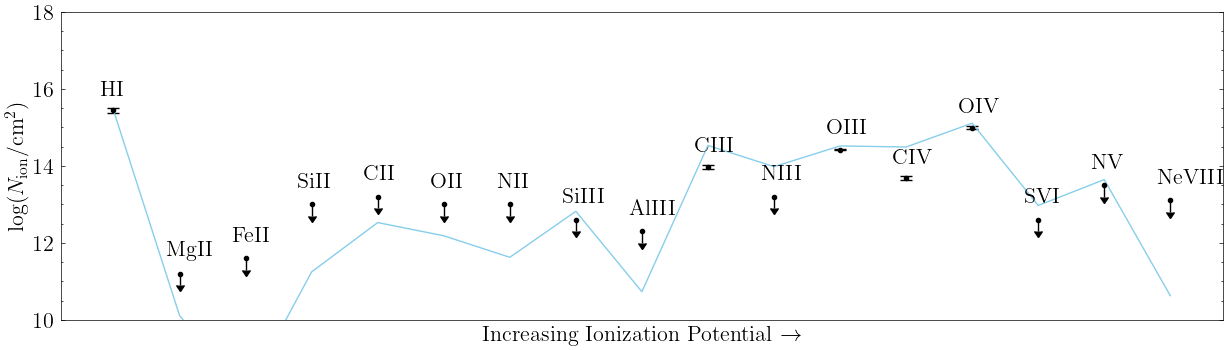

In [17]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

# Single phase solution

Get column density ratios

In [18]:
gen_logN_ratio_str(logN_dict['CIII'], logN_dict['CIV'])

'0.29, -0.08, 0.08'

In [19]:
logN_ratio_dict = {'OIV/SVI': '>2.4, 0.2',
                   'OII/OIII': '<-1.4, 0.1',
                   'OIV/OIII': '0.57, -0.04, 0.06',  
                   'CII/CIII': '<-0.8, 0.2',
                   'CIV/CIII': '-0.29, -0.08, 0.08'
                  }

We had the expression -

$$N_{\mathrm{X_i}} = N_{\mathrm{HI}} \times \frac{f_{X_i}}{f_{\mathrm{HI}}} \times 10^{[\mathrm{X/H}]}$$

So the column density ratio of two ions $X_i$ and $Y_j$ will be given by -

$$\boxed{\frac{N_{\mathrm{X_i}}}{N_{\mathrm{Y_j}}} = \frac{f_{X_i}}{f_{Y_j}} \times 10^{[\mathrm{X/Y}]}}$$

If we assume [X/Y]=0 (as we can for $\alpha$ elements usually, or at least for oxygen and sulphur), then the column density ratio will just be governed by the gas density. 

We can test the hypothesis of the observed column density distribution of ions being explainable by a single gas phase by plotting observed column density ratios and inferring correpsonding gas density ranges. If we can get a consistent range of gas densities, then a single phase solution is feasible. If this test fails, then there are two possibilities -

1. If the ion pair used to infer gas density involves different elements, then their abundance pattern may not be similar (i.e. [X/Y] is not zero)

2. A single gas phase is not sufficient to explain the observed column densities of ions

(-5.0, 5.0)

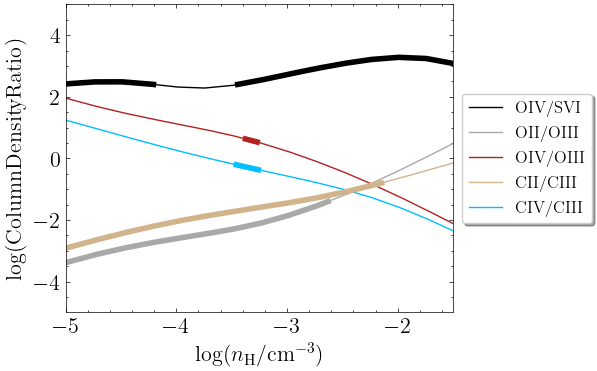

In [20]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

In [21]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [22]:
logN_ratio_dict

{'OIV/SVI': '>2.4, 0.2',
 'OII/OIII': '<-1.4, 0.1',
 'OIV/OIII': '0.57, -0.04, 0.06',
 'CII/CIII': '<-0.8, 0.2',
 'CIV/CIII': '-0.29, -0.08, 0.08'}

In [23]:
#pos = np.array(-3.35) + 1e-4 * np.random.randn(500, 1)
#nwalkers, ndim = pos.shape

In [24]:
#sampler = emcee.EnsembleSampler(
#    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
#)

In [25]:
#sampler.run_mcmc(pos, 500, progress=True);

In [26]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])
#
#flat_samples_hdens.to_csv(savedir+'hdens_op.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_op.csv')

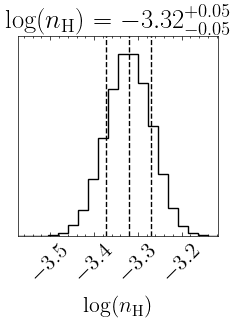

In [27]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [28]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [29]:
logN_offset = 14.42-np.mean(species_logN_interp['O+2'](grid_points_hdens))

In [30]:
logN_offset

5.655109385672585

Calculate the C/O ratio

In [31]:
logN_CIII_obs = np.random.normal(loc=13.97, scale=0.05, size=len(flat_samples_hdens))
logN_CIV_obs = np.random.normal(loc=13.68, scale=0.05, size=len(flat_samples_hdens))

In [32]:
C_O_dist_CIII = logN_CIII_obs-(logN_offset+species_logN_interp['C+2'](grid_points_hdens))
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = np.concatenate((C_O_dist_CIII, C_O_dist_CIV))

In [33]:
get_quantiles(C_O_dist)

-0.56 -0.06 0.07


Plot models

In [34]:
logN_dict = {#'HI':'15.44, -0.06, +0.06',
            'CII':'<13.2',
            'CIII':'13.97, -0.05, +0.05',
            'CIV':'13.68, -0.06, +0.06',
            #'NII':'<13.0',
            #'NIII':'<13.2',
            #'NV':'<13.5',
            'OII':'<13.0',
            'OIII':'14.42, -0.02, +0.02',
            'OIV':'14.99, -0.04, +0.06',
            #'NeVIII':'<13.1',
            'MgII':'<11.2',
            #'AlIII':'<12.3',
            #'SiII':'<13.0',
            #'SiIII':'<12.6',
            'SVI':'<12.6',}
            #'FeII':'<11.6'}

In [35]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

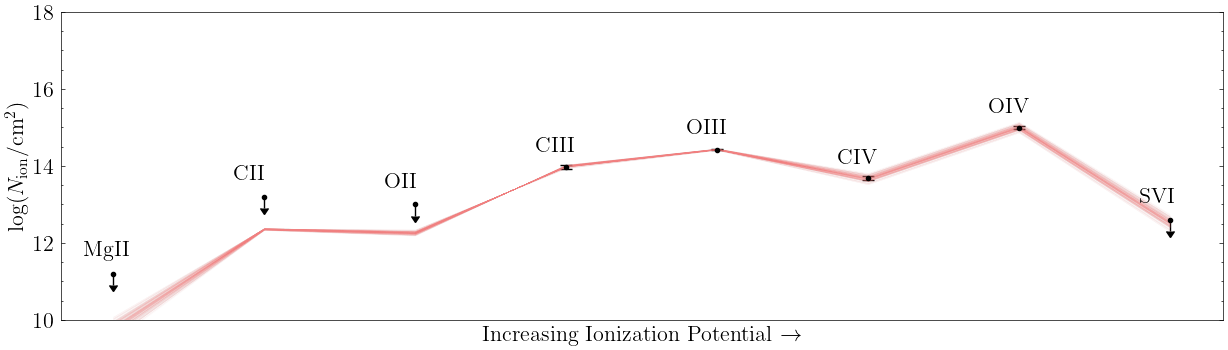

In [36]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp, {'C': np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='lightcoral', lw=.2, alpha=.1)

Plot cloud sizes

In [37]:
get_cloud_size(15.44, -3.3, species_logN_interp)

12.069635563447742

In [38]:
#l_dist = np.array([get_cloud_size(15.44, log_hdens, species_logN_interp) for log_hdens in flat_samples_hdens['log_hdens']])

In [39]:
#plt.hist(l_dist)

In [40]:
#np.median(l_dist)

# Two-phase solution - low density phase

In [183]:
logN_dict = {'HI':'15.44, -0.06, +0.06',
            'CII':'<13.2',
            'CIII':'<13.97',
            'CIV':'13.68, -0.06, +0.06',
            'NII':'<13.0',
            'NIII':'<13.2',
            'NV':'<13.5',
            'OII':'<13.0',
            'OIII':'<14.42',
            'OIV':'14.99, -0.04, +0.06',
            'NeVIII':'<13.1',
            'MgII':'<11.2',
            'AlIII':'<12.3',
            'SiII':'<13.0',
            'SiIII':'<12.6',
            'SVI':'<12.6',
            'FeII':'<11.6'}

Get column density ratios

In [184]:
gen_logN_ratio_str(logN_dict['NV'], logN_dict['OIV'])

'<-1.49, 0.15'

In [185]:
logN_ratio_dict = {'OIII/OIV': '<-0.6, 0.2',
                   'SVI/OIV' : '<-2.4, 0.2',
                   'NeVIII/OIV': '<-1.9, 0.2',
                   'CIII/CIV': '<0.3, 0.2',
                   #'NV/OIV': '<-1.5, 0.2'
                  }

(-5.0, 5.0)

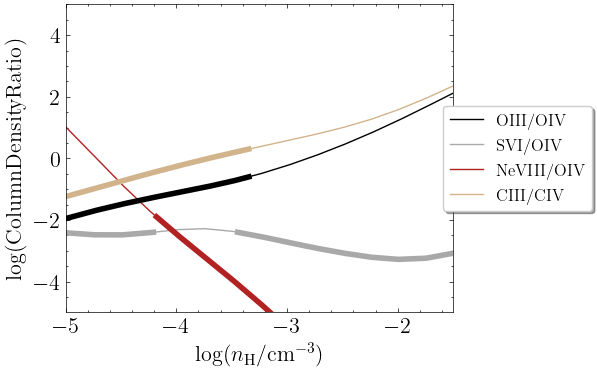

In [186]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

Fit the density

In [187]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [188]:
#pos = np.array(-3.4) + 1e-6 * np.random.randn(500, 1)
#nwalkers, ndim = pos.shape

In [189]:
#sampler = emcee.EnsembleSampler(
#    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
#)

In [190]:
#sampler.run_mcmc(pos, 500, progress=True);

In [191]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_lo.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_lo.csv')

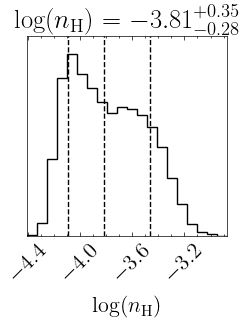

In [194]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [195]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [196]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

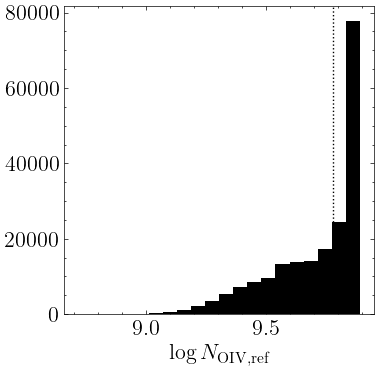

In [197]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{CIV, ref}}$')

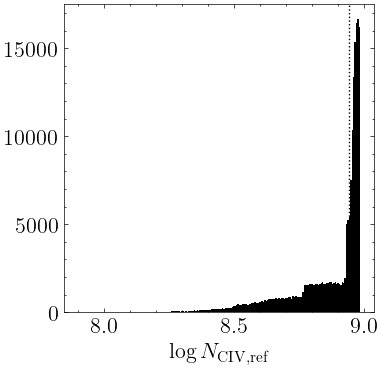

In [198]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['C+3'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['C+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{CIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{OIII, ref}}$')

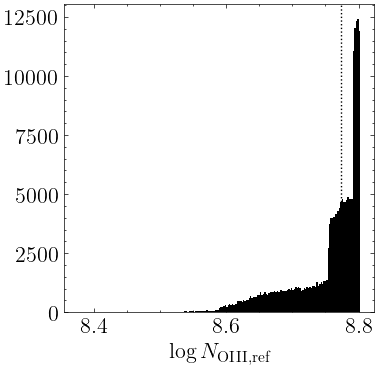

In [199]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['O+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{CIII, ref}}$')

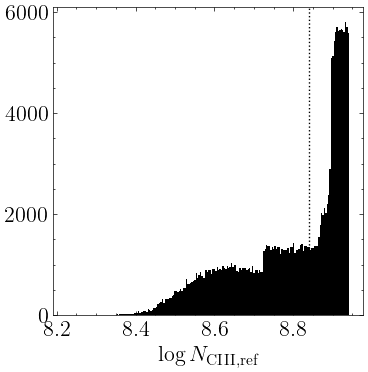

In [200]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['C+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['C+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{CIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [201]:
logN_offset = 14.99-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [202]:
logN_offset

5.210591937216021

Calculate the C/O ratio

In [203]:
logN_CIV_obs = np.random.normal(loc=13.68, scale=0.05, size=len(flat_samples_hdens))

In [204]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [205]:
get_quantiles(C_O_dist)

-0.45 -0.08 0.2


Get yields

In [206]:
#get_quantiles(logN_offset+species_logN_interp['O+3'](grid_points_hdens))

In [207]:
#get_quantiles(logN_offset-0.4+species_logN_interp['C+3'](grid_points_hdens))

In [208]:
get_quantiles(logN_offset-0.5+species_logN_interp['C+2'](grid_points_hdens))

13.55 -0.21 0.08


In [209]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

13.98 -0.08 0.02


Plot models

In [210]:
logN_dict = {#'HI':'15.44, -0.06, +0.06',
            #'CII':'<13.2',
            'CIII':'13.97, -0.05, +0.05',
            'CIV':'13.68, -0.06, +0.06',
            #'NII':'<13.0',
            #'NIII':'<13.2',
            #'NV':'<13.5',
            #'OII':'<13.0',
            'OIII':'14.42, -0.02, +0.02',
            'OIV':'14.99, -0.04, +0.06',
            'NeVIII':'<13.1',
            #'MgII':'<11.2',
            #'AlIII':'<12.3',
            #'SiII':'<13.0',
            #'SiIII':'<12.6',
            'SVI':'<12.6',}
            #'FeII':'<11.6'}

In [211]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

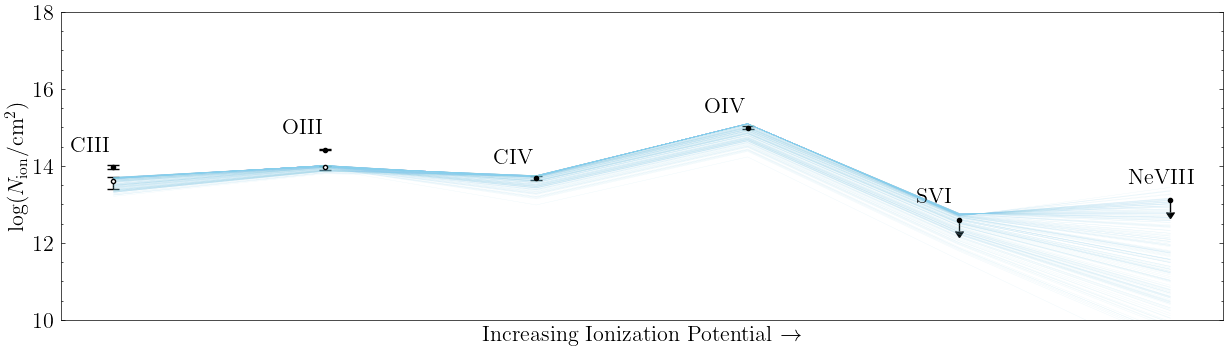

In [212]:
fig, ax = plot_column_densities_obs(logN_dict)

ax.errorbar(x=0, y=13.6, yerr=[[0.2], [0.1]], color='black', linestyle='None', mfc='white',
        fmt='o', markersize=3, capsize=4)

ax.errorbar(x=1, y=13.98, yerr=[[0.08], [0.02]], color='black', linestyle='None', mfc='white',
        fmt='o', markersize=3, capsize=4)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp, {'C': np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)

Calculate residual for CIII

In [213]:
logN_CIII_tot = np.random.normal(loc=13.97, scale=0.05, size=1000)
logN_CIII_lo_dens = np.random.normal(loc=13.5, scale=0.2, size=1000)
logN_CIII_hi_dens = np.log10(10**logN_CIII_tot - 10**logN_CIII_lo_dens)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_76044/1477459586.py:3: RuntimeWarning: invalid value encountered in log10
  logN_CIII_hi_dens = np.log10(10**logN_CIII_tot - 10**logN_CIII_lo_dens)


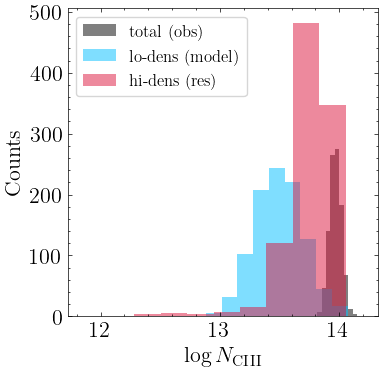

In [214]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_CIII_tot, label='total (obs)', alpha=0.5)
ax.hist(logN_CIII_lo_dens, label='lo-dens (model)', alpha=0.5)
ax.hist(logN_CIII_hi_dens, label='hi-dens (res)', alpha=0.5)

ax.set_xlabel(r'$\log N_{\mathrm{CIII}}$')
ax.set_ylabel('Counts')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [215]:
logN_CIII_hi_dens_clean = logN_CIII_hi_dens[~np.isnan(logN_CIII_hi_dens)]

In [216]:
get_quantiles(logN_CIII_hi_dens_clean)

13.78 -0.17 0.11


Calculate residual for OIII

In [217]:
logN_OIII_tot = np.random.normal(loc=14.42, scale=0.02, size=1000)
logN_OIII_lo_dens = np.random.normal(loc=13.98, scale=0.08, size=1000)
logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)

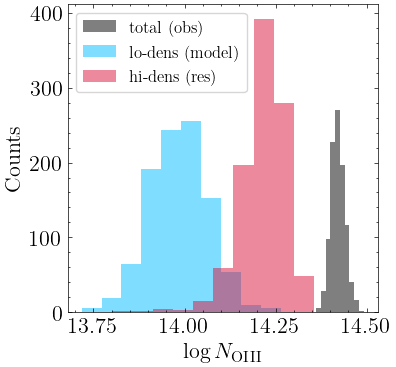

In [218]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_OIII_tot, label='total (obs)', alpha=0.5)
ax.hist(logN_OIII_lo_dens, label='lo-dens (model)', alpha=0.5)
ax.hist(logN_OIII_hi_dens, label='hi-dens (res)', alpha=0.5)

ax.set_xlabel(r'$\log N_{\mathrm{OIII}}$')
ax.set_ylabel('Counts')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [219]:
logN_OIII_hi_dens_clean = logN_OIII_hi_dens[~np.isnan(logN_OIII_hi_dens)]

In [220]:
get_quantiles(logN_OIII_hi_dens_clean)

14.22 -0.06 0.05


# Two-phase solution - high density phase

In [221]:
logN_dict = {'HI':'15.44, -0.06, +0.06',
            'CII':'<13.2',
            'CIII':'13.6, -0.2, +0.1',
            'CIV':'<13.68',
            'NII':'<13.0',
            'NIII':'<13.2',
            'NV':'<13.5',
            'OII':'<13.0',
            'OIII':'14.22, -0.07, +0.05',
            'OIV':'<14.99',
            'NeVIII':'<13.1',
            'MgII':'<11.2',
            'AlIII':'<12.3',
            'SiII':'<13.0',
            'SiIII':'<12.6',
            'SVI':'<12.6',
            'FeII':'<11.6'}

Get column density ratios

In [222]:
gen_logN_ratio_str(logN_dict['MgII'], logN_dict['OIII'])

'<-3.02, 0.15'

In [223]:
logN_ratio_dict = {'CII/CIII': '<-0.4, 0.2',
                   'CIV/CIII': '<0.1, 0.2',
                   'OII/OIII': '<-1.2, 0.2',
                   'OIV/OIII': '<0.8, 0.2',
                   'MgII/OIII':  '<-3.0, 0.2'
                  }

(-5.0, 5.0)

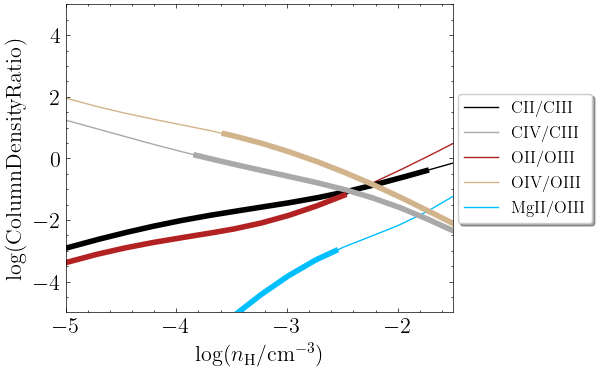

In [225]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

In [226]:
#pos = np.array(-3) + 1e-6 * np.random.randn(500, 1)
#nwalkers, ndim = pos.shape

In [227]:
#sampler = emcee.EnsembleSampler(
#    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
#)

In [228]:
#sampler.run_mcmc(pos, 500, progress=True);

In [229]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_hi.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_hi.csv')

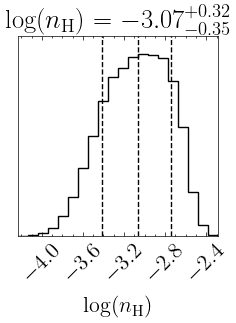

In [230]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [127]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [128]:
logN_offset = 14.22-np.median(species_logN_interp['O+2'](grid_points_hdens))

In [129]:
logN_offset

5.510986620884607

Calculate the C/O ratio

In [130]:
logN_CIII_obs = np.random.normal(loc=13.6, scale=0.2, size=len(flat_samples_hdens))

In [131]:
C_O_dist_CIII = logN_CIII_obs-(logN_offset+species_logN_interp['C+2'](grid_points_hdens))
C_O_dist = C_O_dist_CIII

In [132]:
get_quantiles(C_O_dist)

-0.62 -0.27 0.31


Plot models

In [133]:
logN_dict = {#'HI':'15.44, -0.06, +0.06',
            'CII':'<13.2',
            'CIII':'13.6, -0.2, +0.1',
            'CIV':'<13.68',
            #'NII':'<13.0',
            #'NIII':'<13.2',
            #'NV':'<13.5',
            'OII':'<13.0',
            'OIII':'14.22, -0.07, +0.05',
            'OIV':'<14.99',
            #'NeVIII':'<13.1',
            'MgII':'<11.2',}
            #'AlIII':'<12.3',
            #'SiII':'<13.0',
            #'SiIII':'<12.6',
            #'SVI':'<12.6',
            #'FeII':'<11.6'}

In [134]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

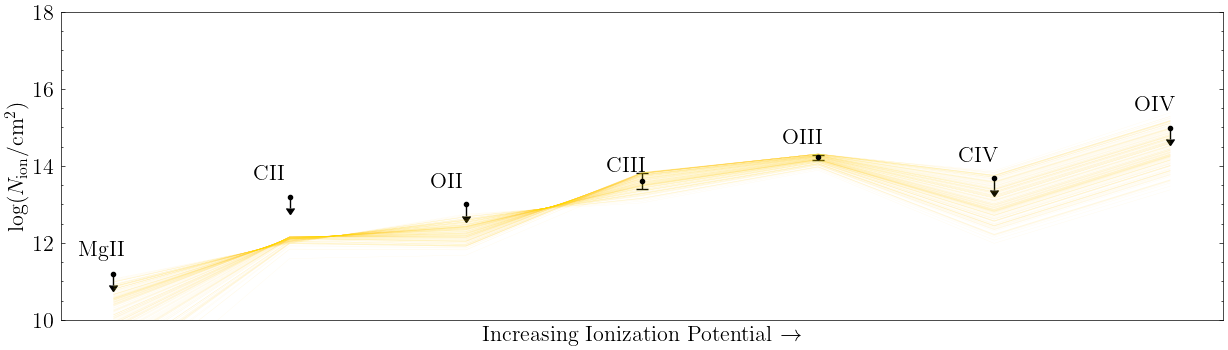

In [135]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp, {'C': np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='gold', lw=.2, alpha=.1)

In [231]:
get_cloud_size(15.44, -3.0, species_logN_interp)

2.691971751119622

# Two-phase solution - simultaneous

In [136]:
logN_dict = {#'HI':'15.44, -0.06, +0.06',
            'CII':'<13.2',
            'CIII':'13.97, -0.05, +0.05',
            'CIV':'13.68, -0.06, +0.06',
            #'NII':'<13.0',
            #'NIII':'<13.2',
            #'NV':'<13.5',
            'OII':'<13.0',
            'OIII':'14.42, -0.02, +0.02',
            'OIV':'14.99, -0.04, +0.06',
            'NeVIII':'<13.1',
            'MgII':'<11.2',
            #'AlIII':'<12.3',
            #'SiII':'<13.0',
            #'SiIII':'<12.6',
            'SVI':'<12.6',}
            #'FeII':'<11.6'}

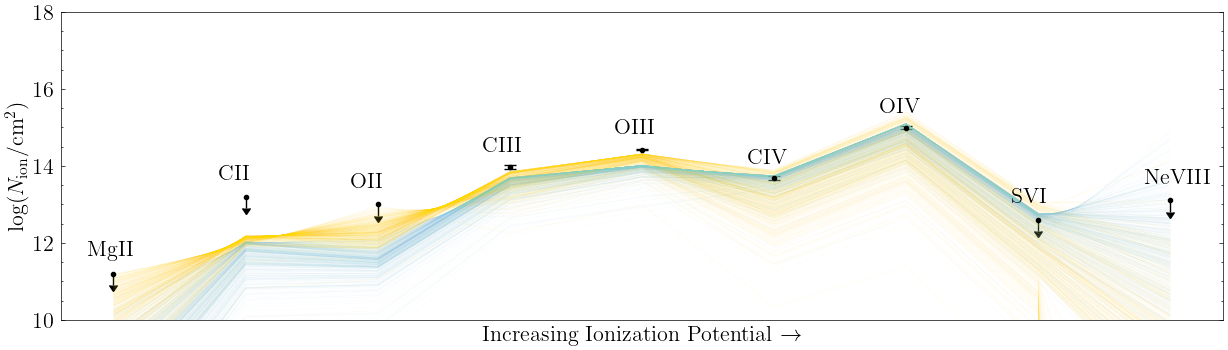

In [137]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(400):
    
    log_hdens_hi = np.random.normal(loc=-3.1, scale=0.4)
    log_hdens_lo = np.random.normal(loc=-3.8, scale=0.4)
    
    if log_hdens_min<log_hdens_hi<log_hdens_max and log_hdens_min<log_hdens_lo<log_hdens_max:
        
        logN_species_test_hi = np.array(predict_col_dens(logN_dict, 12, log_hdens_hi, 
                                             -3, species_logN_interp, {'C': -0.6}))+5.51

        logN_species_test_lo = np.array(predict_col_dens(logN_dict, 12, log_hdens_lo, 
                                             -3, species_logN_interp, {'C': -0.45}))+5.21

        logN_species_test = np.log10(10**logN_species_test_hi + 10**logN_species_test_lo)

        # Plot
        ax.plot(np.arange(len(logN_species_test_hi)), 
                np.array(logN_species_test_hi),
                color='gold', lw=.2, alpha=.1)

        # Plot
        ax.plot(np.arange(len(logN_species_test_lo)), 
                np.array(logN_species_test_lo),
                color='skyblue', lw=.2, alpha=.1)    

        #ax.plot(np.arange(len(logN_species_test)), 
        #        np.array(logN_species_test),
        #        color='lightcoral', lw=.2, alpha=.1)  

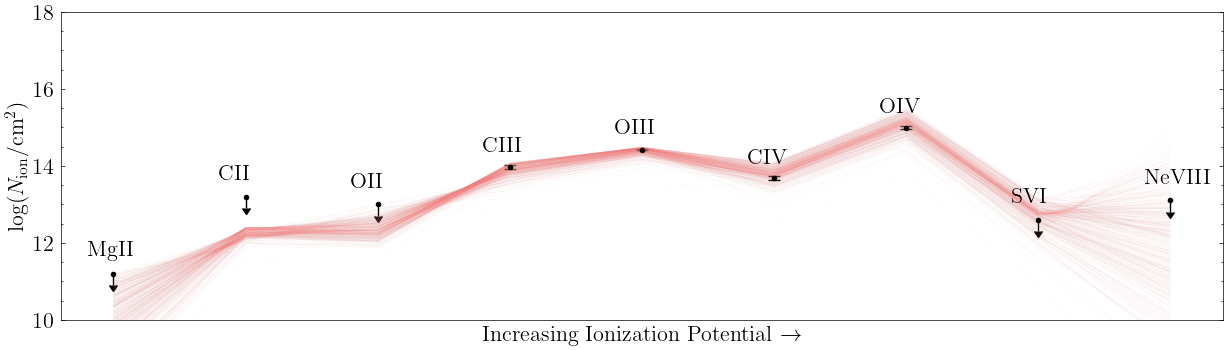

In [138]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(400):
    
    log_hdens_hi = np.random.normal(loc=-3.1, scale=0.4)
    log_hdens_lo = np.random.normal(loc=-3.8, scale=0.4)
    
    if log_hdens_min<log_hdens_hi<log_hdens_max and log_hdens_min<log_hdens_lo<log_hdens_max:
        
        logN_species_test_hi = np.array(predict_col_dens(logN_dict, 12, log_hdens_hi, 
                                             -3, species_logN_interp, {'C': -0.6}))+5.51

        logN_species_test_lo = np.array(predict_col_dens(logN_dict, 12, log_hdens_lo, 
                                             -3, species_logN_interp, {'C': -0.45}))+5.21

        logN_species_test = np.log10(10**logN_species_test_hi + 10**logN_species_test_lo)

        # Plot
        #ax.plot(np.arange(len(logN_species_test_hi)), 
        #        np.array(logN_species_test_hi),
        #        color='gold', lw=.2, alpha=.1)

        # Plot
        #ax.plot(np.arange(len(logN_species_test_lo)), 
        #        np.array(logN_species_test_lo),
        #        color='skyblue', lw=.2, alpha=.1)    

        ax.plot(np.arange(len(logN_species_test)), 
                np.array(logN_species_test),
                color='lightcoral', lw=.2, alpha=.1)  

# Higher density phase

In [165]:
def lambda_log_prior(params):
    

    # Grid parameters being varied
    log_hdens, log_metals = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    if -3.3<log_hdens<log_hdens_max and log_metals_min<log_metals<log_metals_max:
        return 0.0
    return -np.inf

In [166]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    log_hdens, log_metals = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([15.44, log_hdens, log_metals])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood_scale(params_full, logN_dict, species_logN_interp)    

In [167]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Fit things

In [168]:
logN_dict = {#'HI':'<15.44',
            #'CII':'<13.2',
            #'CIII':'<13.97',
            #'CIV':'<13.68',
            #'NII':'<13.0',
            #'NIII':'<13.2',
            #'NV':'<13.5',
            'OII':'<13.0',
            'OIII':'<14.42',
            #'OIV':'<14.99',
            #'NeVIII':'<13.1',
            'MgII':'<11.2',}
            #'AlIII':'<12.3',
            #'SiII':'<13.0',
            #'SiIII':'<12.6',
            #'SVI':'<12.6',}
            #'FeII':'<11.6'}

In [169]:
logN_HI_test = 15.44
log_hdens_test = -1
log_metals_test = -0.7

In [170]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, log_metals_test, species_logN_interp)

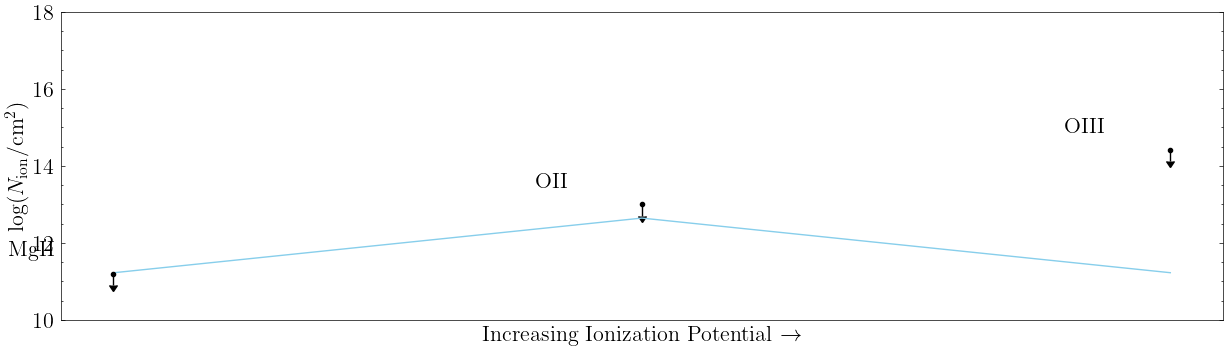

In [171]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

In [172]:
pos = np.array([-1, -1]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [173]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict, species_logN_interp)
)

In [174]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [02:41<00:00,  3.10it/s]


In [175]:
flat_samples_hier_dens_1 = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens', 'log_metals'])
flat_samples_hier_dens_1.to_csv(savedir+'hdens_hier_1.csv', index=False)

#flat_samples_hier_dens_1 = pd.read_csv(savedir+'hdens_hier_1.csv')

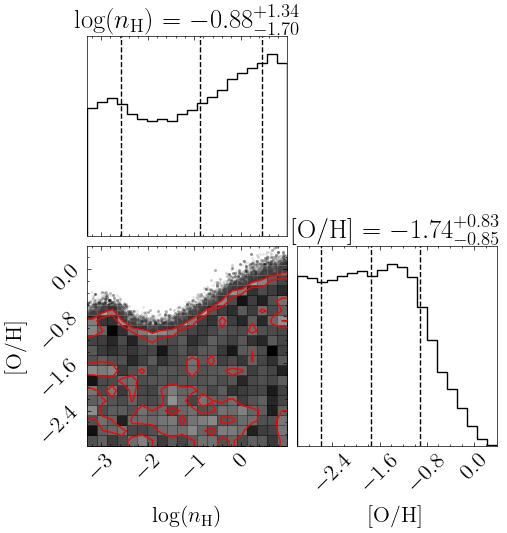

In [176]:
fig = corner.corner(
    flat_samples_hier_dens_1, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [180]:
logN_dict = {#'HI':'<15.44',
            'CII':'<13.2',
            'CIII':'13.97, -0.05, +0.05',
            'CIV':'13.68, -0.06, +0.06',
            'NII':'<13.0',
            'NIII':'<13.2',
            'NV':'<13.5',
            'OII':'<13.0',
            'OIII':'14.42, -0.02, +0.02',
            'OIV':'14.99, -0.04, +0.06',
            'NeVIII':'<13.1',
            'MgII':'<11.2',
            #'AlIII':'<12.3',
            'SiII':'<13.0',
            'SiIII':'<12.6',
            #'SVI':'<12.6',}
            'FeII':'<11.6'}

In [181]:
sample_indices_hier = np.random.randint(low=0, high=len(flat_samples_hier_dens_1), size=500)

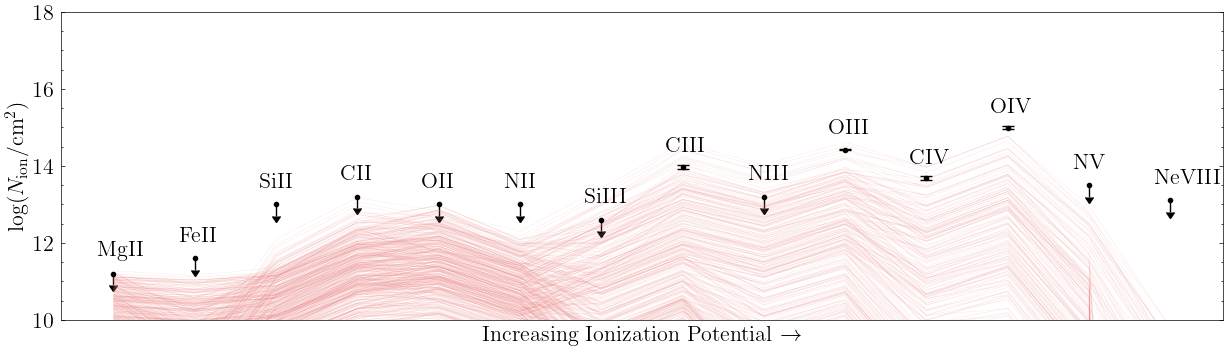

In [182]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hier)):
    
    idx = sample_indices_hier[i]
    flat_samples_row = flat_samples_hier_dens_1.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    logN_species_test = (15.44-12)+(log_metals+3)+np.array(predict_col_dens(logN_dict, 
                                                                              12, 
                                                                              log_hdens, 
                                                                              -3, 
                                                                              species_logN_interp))
    
    #logN_species_test[0] = 15.44

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.3)